# Fraud Detection – Data Cleaning & Exploratory Data Analysis (EDA)

**Project:** Fraud Detection for E-commerce Transactions  
**Company:** Adey Innovations Inc.  

This notebook focuses on:
- Cleaning raw transaction data
- Handling missing values and duplicates
- Exploring data distributions
- Integrating geolocation data
- Engineering initial fraud-related features

The output of this notebook will be a clean, analysis-ready dataset for modeling.


## 1. Import Required Libraries

We import standard Python libraries for data manipulation, visualization, and exploration.


In [1]:
import pandas as pd 
import numpy as np 
import matplotlib.pyplot as plt
import seaborn as sns 

pd.set_option('display.max_columns', None)
plt.style.use('default')
print("Correct")

Correct


## 2. Load Raw Datasets

We load the raw e-commerce transaction data and the IP-to-country mapping dataset.


In [2]:
fraud = pd.read_csv('../data/raw/Fraud_Data.csv')
ip = pd.read_csv('../data/raw/IpAddress_to_Country.csv')  

## 3. Initial Data Inspection

We examine the structure of the dataset to identify:
- Missing values
- Incorrect data types
- Duplicate records


In [3]:
fraud.head()

,user_id,signup_time,purchase_time,purchase_value,device_id,source,browser,sex,age,ip_address,class
0,22058,2015-02-24 22:55:49,2015-04-18 02:47:11,34,QVPSPJUOCKZAR,SEO,Chrome,M,39,7.327584e+08,0
1,333320,2015-06-07 20:39:50,2015-06-08 01:38:54,16,EOGFQPIZPYXFZ,Ads,Chrome,F,53,3.503114e+08,0
2,1359,2015-01-01 18:52:44,2015-01-01 18:52:45,15,YSSKYOSJHPPLJ,SEO,Opera,M,53,2.621474e+09,1
3,150084,2015-04-28 21:13:25,2015-05-04 13:54:50,44,ATGTXKYKUDUQN,SEO,Safari,M,41,3.840542e+09,0
4,221365,2015-07-21 07:09:52,2015-09-09 18:40:53,39,NAUITBZFJKHWW,Ads,Safari,M,45,4.155831e+08,0


In [4]:
fraud.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 151112 entries, 0 to 151111
Data columns (total 11 columns):
 #   Column          Non-Null Count   Dtype  
---  ------          --------------   -----  
 0   user_id         151112 non-null  int64  
 1   signup_time     151112 non-null  object 
 2   purchase_time   151112 non-null  object 
 3   purchase_value  151112 non-null  int64  
 4   device_id       151112 non-null  object 
 5   source          151112 non-null  object 
 6   browser         151112 non-null  object 
 7   sex             151112 non-null  object 
 8   age             151112 non-null  int64  
 9   ip_address      151112 non-null  float64
 10  class           151112 non-null  int64  
dtypes: float64(1), int64(4), object(6)
memory usage: 12.7+ MB


In [5]:
fraud.isnull().sum()

user_id           0
signup_time       0
purchase_time     0
purchase_value    0
device_id         0
source            0
browser           0
sex               0
age               0
ip_address        0
class             0
dtype: int64

In [6]:
fraud.duplicated().sum()

np.int64(0)

## 4. Remove Duplicate Records

Duplicate transactions can bias fraud frequency and must be removed.


In [7]:
fraud.drop_duplicates(inplace=True)
ip.drop_duplicates(inplace=True)

## 5. Handling Missing Values

- Critical fields such as user ID and purchase time are required and rows missing them are dropped.
- Numerical features are imputed using the median.
- Categorical features are imputed using the most frequent value.


In [8]:
fraud.dropna(subset=['user_id', 'purchase_time', 'class'], inplace=True)

fraud['age'].fillna(fraud['age'].median(), inplace=True)  
fraud['browser'].fillna(fraud['browser'].mode()[0], inplace=True)
fraud['source'].fillna(fraud['source'].mode()[0], inplace=True) 


C:\Users\HomePC\AppData\Local\Temp\ipykernel_17012\1927473793.py:3: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  fraud['age'].fillna(fraud['age'].median(), inplace=True)
C:\Users\HomePC\AppData\Local\Temp\ipykernel_17012\1927473793.py:4: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy

## 6. Data Type Correction

Time-related columns are converted to datetime format and IP addresses are converted to integers for geolocation analysis.


In [9]:
fraud['signup_time'] = pd.to_datetime(fraud['signup_time'])
fraud['purchase_time'] = pd.to_datetime(fraud['purchase_time']) 
fraud['ip_address'] = fraud['ip_address'].astype(int)

ip['lower_bound_ip_address'] = ip['lower_bound_ip_address'].astype(int)
ip['upper_bound_ip_address'] = ip['upper_bound_ip_address'].astype(int)

## 7. Validate and Clean Invalid Values

We remove:
- Users with unrealistic ages
- Transactions with non-positive purchase values


In [10]:
fraud = fraud[(fraud['age'] >= 18) & (fraud['age'] <= 100)]
fraud = fraud[fraud['purchase_value'] > 0]

## 8. Standardize Categorical Variables

Standardizing text data prevents duplicated categories caused by inconsistent capitalization or spacing.


In [11]:
fraud['sex'] = fraud['sex'].str.upper().str.strip()
fraud['browser'] = fraud['browser'].str.lower().str.strip()
fraud['source'] = fraud['source'].str.lower().str.strip()

## 9. Class Distribution Analysis

Fraud detection datasets are highly imbalanced. Understanding the class distribution is critical before modeling.


In [12]:
fraud['class'].value_counts()

class
0    136961
1     14151
Name: count, dtype: int64

In [13]:
fraud['class'].value_counts(normalize=True)*100

class
0    90.635423
1     9.364577
Name: proportion, dtype: float64

## 10. Univariate Analysis

We explore the distributions of important numerical features.


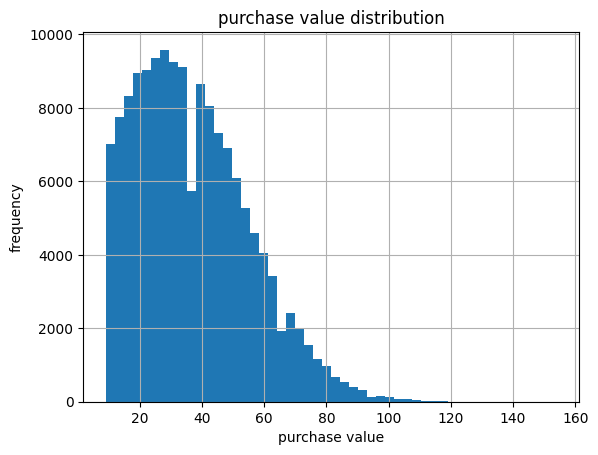

In [14]:
fraud['purchase_value'].hist(bins=50)
plt.title("purchase value distribution")
plt.xlabel("purchase value")
plt.ylabel("frequency")
plt.show()

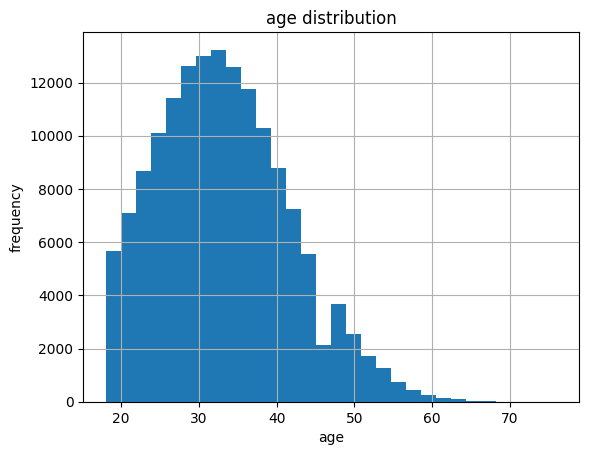

In [15]:
fraud['age'].hist(bins=30)
plt.title("age distribution")
plt.xlabel("age")
plt.ylabel("frequency") 
plt.show()


## 11. Bivariate Analysis

We analyze the relationship between transaction value and fraud occurrence.


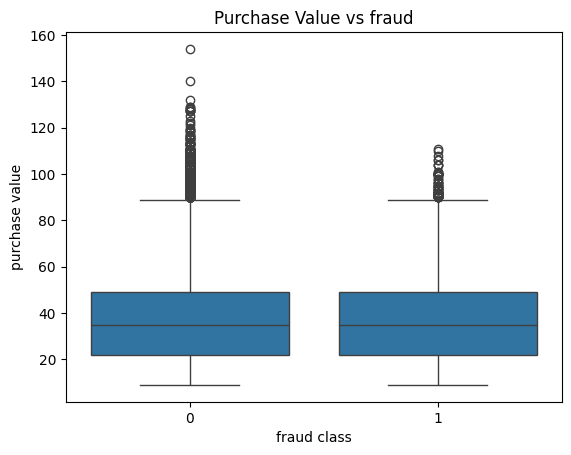

In [16]:
sns.boxplot(x='class', y='purchase_value', data=fraud)
plt.title("Purchase Value vs fraud")
plt.xlabel("fraud class")
plt.ylabel("purchase value")
plt.show()

## 12. Geolocation Integration (IP to Country)

We merge the transaction dataset with IP-to-country mapping using a range-based join.


In [17]:
fraud = fraud.sort_values('ip_address')
ip = ip.sort_values('lower_bound_ip_address')

fraud['country'] = pd.merge_asof(
  fraud,
  ip,
  left_on='ip_address',
  right_on='lower_bound_ip_address',
  direction='backward'
)['country']

## 13. Fraud Rate by Country

This analysis helps identify geographical regions with higher fraud risk.


In [18]:
fraud.groupby('country')['class'].mean().sort_values(ascending=False).head(10)

country
Yemen                    1.000000
Virgin Islands (U.S.)    0.666667
Lesotho                  0.500000
Cayman Islands           0.500000
Bermuda                  0.500000
Monaco                   0.333333
Afghanistan              0.333333
Curacao                  0.333333
Reunion                  0.333333
Iraq                     0.250000
Name: class, dtype: float64

## 14. Time-Based Feature Engineering

We create features that capture temporal patterns often associated with fraud.


In [19]:
fraud['hour_of_day'] = fraud['purchase_time'].dt.hour
fraud['day_of_week'] = fraud['purchase_time'].dt.dayofweek

fraud['time_since_signup'] = (
  fraud['purchase_time'] - fraud['signup_time']
).dt.total_seconds()

## 15. Transaction Velocity Features

Rapid successive transactions are a common indicator of fraudulent behavior.


In [20]:
fraud = fraud.sort_values(['user_id', 'purchase_time'])

fraud['time_diff'] = fraud.groupby('user_id')['purchase_time'].diff().dt.total_seconds()
fraud['rapid_transactions'] = fraud['time_diff'] < 3600

## 16. Final Data Validation and Saving

We perform final validation checks and save the cleaned dataset for modeling.


In [21]:
fraud.info()

<class 'pandas.core.frame.DataFrame'>
Index: 151112 entries, 116708 to 109602
Data columns (total 17 columns):
 #   Column              Non-Null Count   Dtype         
---  ------              --------------   -----         
 0   user_id             151112 non-null  int64         
 1   signup_time         151112 non-null  datetime64[ns]
 2   purchase_time       151112 non-null  datetime64[ns]
 3   purchase_value      151112 non-null  int64         
 4   device_id           151112 non-null  object        
 5   source              151112 non-null  object        
 6   browser             151112 non-null  object        
 7   sex                 151112 non-null  object        
 8   age                 151112 non-null  int64         
 9   ip_address          151112 non-null  int64         
 10  class               151112 non-null  int64         
 11  country             150478 non-null  object        
 12  hour_of_day         151112 non-null  int32         
 13  day_of_week         151112 no

In [22]:
fraud.isnull().sum()

user_id                    0
signup_time                0
purchase_time              0
purchase_value             0
device_id                  0
source                     0
browser                    0
sex                        0
age                        0
ip_address                 0
class                      0
country                  634
hour_of_day                0
day_of_week                0
time_since_signup          0
time_diff             151112
rapid_transactions         0
dtype: int64

In [23]:
fraud.to_csv('../data/processed/fraud_data_cleaned.csv', index=False)